# 04 — Evaluation & Analysis

Full evaluation across all 5 models × 5 horizons. Requires:
- `results/classical_results.pkl` (from notebook 02)
- `results/neural_results.pkl`    (from notebook 03)
- `models/lstm_k*.pt`             (from notebook 03)
- `models/deeplob_k*.pt`          (from notebook 03)

Sections:
1. Unified weighted-F1 results table
2. Inference throughput
3. Confusion matrices at k=10
4. Ablation C — SimpleLSTM vs DeepLOB (value of CNN spatial extraction)
5. Backtest-style proxy simulation — cumulative normalized P&L and segment t-statistics
6. Error analysis

In [2]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

NVIDIA RTX A5000
True


In [4]:
import sys, os, pickle, time
import socket
if socket.gethostname().startswith('compsci'):
    PROJECT_ROOT = os.path.expanduser('~/deeplob-midprice-prediction')
else:
    PROJECT_ROOT = os.path.expanduser('~/CS372/deeplob-midprice-prediction')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.data_loader import load_raw, extract_features_labels, temporal_split, SlidingWindowDataset, make_loader
from src.features import add_engineered_features
from src.models.baseline import MajorityClassifier
from src.models.logistic import LogisticModel
from src.models.xgboost_model import XGBoostModel
from src.models.lstm_baseline import SimpleLSTM
from src.models.deeplob import DeepLOB
from src.train import load_checkpoint, DEVICE
from src.evaluate import compute_metrics, build_results_table, get_confusion_matrix
from src.backtest import extract_mid_prices, infer_segment_boundaries, run_backtest, compute_tstat

MODELS  = os.path.join(PROJECT_ROOT, 'models')
RESULTS = os.path.join(PROJECT_ROOT, 'results')
DATA    = os.path.join(PROJECT_ROOT, 'data', 'raw')
os.makedirs(RESULTS, exist_ok=True)

HORIZONS = [1, 2, 3, 5, 10]
WINDOW   = 100

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'Device: {DEVICE}')

Device: cuda


## 1. Load data and saved results

In [5]:
train_df = load_raw(os.path.join(DATA, 'FI2010_train.csv'))
test_df  = load_raw(os.path.join(DATA, 'FI2010_test.csv'))

X_all, Y_all   = extract_features_labels(train_df)
X_test, Y_test = extract_features_labels(test_df)
X_train, Y_train, X_val, Y_val = temporal_split(X_all, Y_all)

X_train_eng = add_engineered_features(X_train)
X_test_eng  = add_engineered_features(X_test)

with open(os.path.join(RESULTS, 'classical_results.pkl'), 'rb') as f:
    classical = pickle.load(f)

with open(os.path.join(RESULTS, 'neural_results.pkl'), 'rb') as f:
    neural = pickle.load(f)

print('Classical keys:', list(classical.keys()))
print('Neural keys:   ', list(neural.keys()))

Classical keys: ['majority', 'logistic', 'xgboost', 'xgb_best_configs', 'ablation_a_raw', 'ablation_a_eng', 'ablation_b_unw', 'ablation_b_bal']
Neural keys:    ['lstm', 'deeplob', 'lstm_histories', 'deeplob_histories']


## 2. Unified Results Table

Weighted F1 on the test set (days 8–10) for all 5 models × 5 horizons.
Paper comparison point: DeepLOB at k=10 → target F1 ≈ 0.834 (Table II, Setup 2).
k=1,2,3,5 are not in the paper (paper uses k=10,20,50 with recomputed labels).

Weighted F1 on test set:
              k=1    k=2    k=3    k=5   k=10
Majority   0.5352 0.4131 0.3389 0.2341 0.2123
Logistic   0.5297 0.4779 0.4498 0.4057 0.3677
XGBoost    0.5733 0.4895 0.4811 0.4623 0.4169
SimpleLSTM 0.7667 0.6554 0.6817 0.6956 0.6472
DeepLOB    0.7888 0.6844 0.7273 0.7404 0.3406


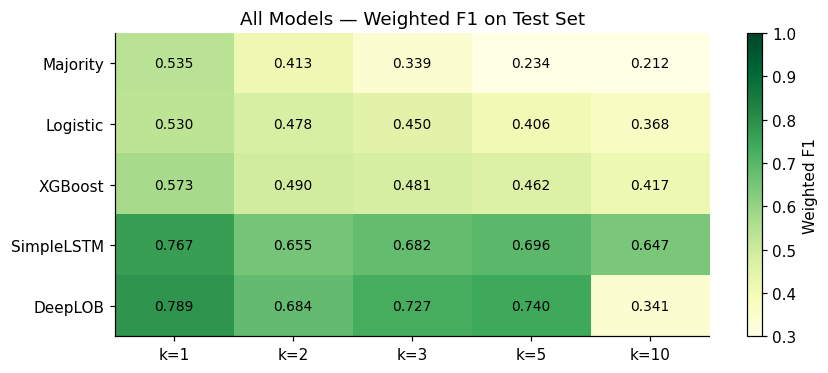

In [6]:
all_results = {
    'Majority':   classical['majority'],
    'Logistic':   classical['logistic'],
    'XGBoost':    classical['xgboost'],
    'SimpleLSTM': neural['lstm'],
    'DeepLOB':    neural['deeplob'],
}

table = build_results_table(all_results)
print('Weighted F1 on test set:')
print(table.to_string(float_format='{:.4f}'.format))

# Heatmap
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(table.values.astype(float), cmap='YlGn', aspect='auto', vmin=0.3, vmax=1.0)
ax.set_xticks(range(len(HORIZONS))); ax.set_xticklabels([f'k={k}' for k in HORIZONS])
ax.set_yticks(range(len(table))); ax.set_yticklabels(table.index)
for i in range(len(table)):
    for j in range(len(HORIZONS)):
        ax.text(j, i, f'{table.values[i, j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Weighted F1')
ax.set_title('All Models — Weighted F1 on Test Set', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'results_table.png'), bbox_inches='tight')
plt.show()

### Key findings

The gap between classical and neural models is large and consistent. At k=1, XGBoost reaches F1=0.573 while SimpleLSTM jumps to 0.767 (+0.194) and DeepLOB to 0.789 (+0.216). The improvement holds across all short horizons — temporal modeling captures structure that snapshot-based models cannot see.

The k=10 horizon is the exception. DeepLOB's F1 collapses to 0.341, well below XGBoost (0.417) and far below SimpleLSTM (0.647). This reversal is examined in the ablation below.

## 3. Inference Throughput

Predictions per second for each model. Measured on a batch of 512 samples, 10 timed passes.

In [7]:
# Retrain classical models at k=1 (fast) to get callable predict functions
print('Retraining classical models at k=1 for throughput measurement...')

maj_clf = MajorityClassifier().fit(X_train, Y_train[:, 0])

lr_clf = LogisticModel().fit(X_train, Y_train[:, 0])

xgb_clf = XGBoostModel()
xgb_clf.fit(X_train_eng, Y_train[:, 0], config=classical['xgb_best_configs'][0])

# Load neural checkpoints at k=1
lstm_model = load_checkpoint(SimpleLSTM(), os.path.join(MODELS, 'lstm_k1.pt')).eval().to(DEVICE)
dlob_model = load_checkpoint(DeepLOB(),    os.path.join(MODELS, 'deeplob_k1.pt')).eval().to(DEVICE)

# Build a 512-sample window batch for timing
test_windows = np.stack([X_test[i:i+WINDOW] for i in range(512)])
test_windows_eng = add_engineered_features(test_windows.reshape(-1, 40)).reshape(512, WINDOW, 53)
X_snap     = X_test[:512]
X_snap_eng = X_test_eng[:512]

def time_predict(fn, n_warmup=3, n_timed=10):
    for _ in range(n_warmup): fn()
    t0 = time.perf_counter()
    for _ in range(n_timed): fn()
    return (512 * n_timed) / (time.perf_counter() - t0)

def nn_predict(model, windows):
    x = torch.from_numpy(windows).to(DEVICE)
    with torch.no_grad():
        return model(x).argmax(1).cpu().numpy()

throughputs = {
    'Majority':   time_predict(lambda: maj_clf.predict(X_snap)),
    'Logistic':   time_predict(lambda: lr_clf.predict(X_snap)),
    'XGBoost':    time_predict(lambda: xgb_clf.predict(X_snap_eng)),
    'SimpleLSTM': time_predict(lambda: nn_predict(lstm_model, test_windows)),
    'DeepLOB':    time_predict(lambda: nn_predict(dlob_model, test_windows)),
}

print('\nInference throughput (predictions/second):')
for name, tput in throughputs.items():
    print(f'  {name:<12}  {tput:>12,.0f} pred/s')

Retraining classical models at k=1 for throughput measurement...

Inference throughput (predictions/second):
  Majority       277,402,268 pred/s
  Logistic         4,776,245 pred/s
  XGBoost            125,294 pred/s
  SimpleLSTM         302,284 pred/s
  DeepLOB             83,472 pred/s


/usr/pkg/miniconda-23.9.0/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/conda/conda-bld/pytorch_1695392035891/work/aten/src/ATen/native/Convolution.cpp:1008.)
  return F.conv2d(input, weight, bias, self.stride,


### Interpretation

Classical models are fastest with no sequence overhead. SimpleLSTM is surprisingly competitive on GPU — the 2-layer LSTM over 100 timesteps runs nearly 4× faster than DeepLOB because it has no convolutional front-end. DeepLOB's 83K pred/s is still fast enough for real-time use: typical LOB event rates are in the hundreds per second.

## 4. Confusion Matrices at k=10

Rows = true class, columns = predicted class. Shows where each model makes systematic errors.

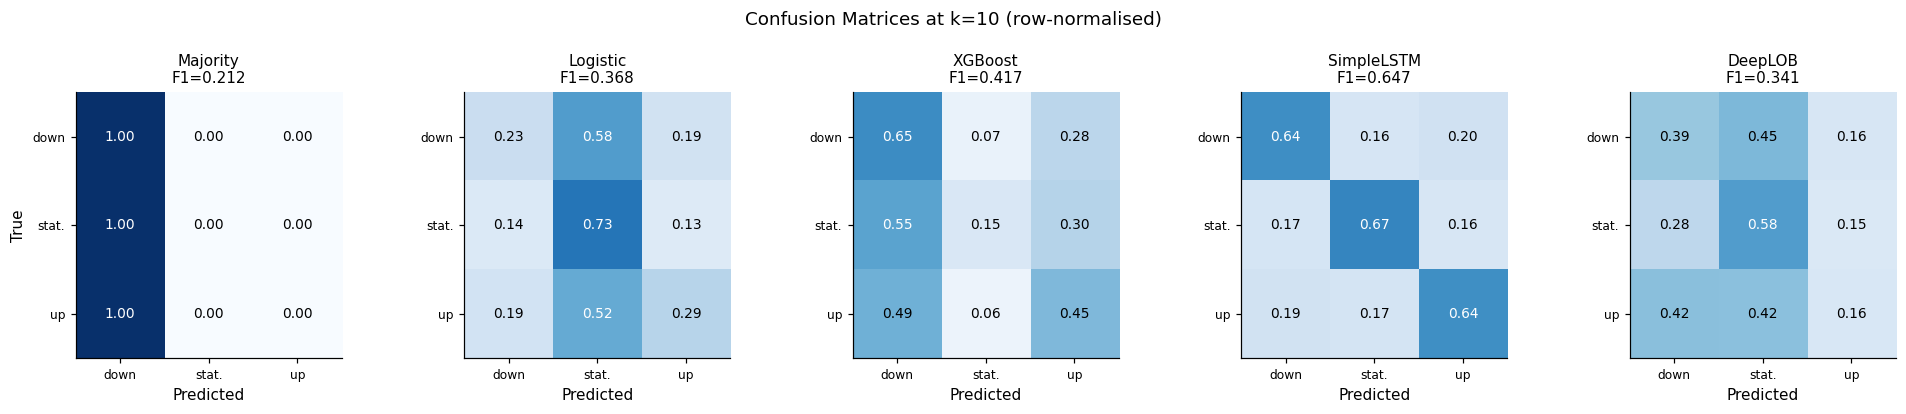

In [9]:
# Re-run inference at k=10 to get raw prediction arrays
h_idx_10 = HORIZONS.index(10)
y_true_10 = Y_test[WINDOW - 1:-1, h_idx_10]  # N-WINDOW items, aligned to sliding windows

def get_classical_preds_k10(clf, X):
    return clf.predict(X[WINDOW - 1:-1])  # drop first 99 and last row to match window count

def get_nn_preds(model, X, Y, h_idx):
    ds = SlidingWindowDataset(X, Y, window=WINDOW, horizon_idx=h_idx)
    loader = make_loader(ds, batch_size=512, shuffle=False)
    preds = []
    model.eval()
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

lstm_k10  = load_checkpoint(SimpleLSTM(), os.path.join(MODELS, 'lstm_k10.pt')).eval().to(DEVICE)
dlob_k10  = load_checkpoint(DeepLOB(),    os.path.join(MODELS, 'deeplob_k10.pt')).eval().to(DEVICE)

# Retrain majority and LR at k=10 quickly
maj_k10 = MajorityClassifier().fit(X_train, Y_train[:, h_idx_10])
lr_k10  = LogisticModel().fit(X_train, Y_train[:, h_idx_10])
xgb_k10 = XGBoostModel()
xgb_k10.fit(X_train_eng, Y_train[:, h_idx_10], config=classical['xgb_best_configs'][h_idx_10])

preds_k10 = {
    'Majority':   get_classical_preds_k10(maj_k10,  X_test),
    'Logistic':   get_classical_preds_k10(lr_k10,   X_test),
    'XGBoost':    get_classical_preds_k10(xgb_k10,  X_test_eng),
    'SimpleLSTM': get_nn_preds(lstm_k10, X_test, Y_test, h_idx_10),
    'DeepLOB':    get_nn_preds(dlob_k10, X_test, Y_test, h_idx_10),
}

CLASS_NAMES = ['down', 'stat.', 'up']
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, (name, preds) in zip(axes, preds_k10.items()):
    cm = get_confusion_matrix(y_true_10, preds).astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)  # row-normalise
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if cm_norm[i,j] > 0.5 else 'black')
    ax.set_xticks([0,1,2]); ax.set_xticklabels(CLASS_NAMES, fontsize=8)
    ax.set_yticks([0,1,2]); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    f1 = compute_metrics(y_true_10, preds)['weighted_f1']
    ax.set_title(f'{name}\nF1={f1:.3f}', fontsize=10)
    if ax == axes[0]: ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

fig.suptitle('Confusion Matrices at k=10 (row-normalised)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'confusion_matrices_k10.png'), bbox_inches='tight')
plt.show()

### Interpretation

At k=10, DeepLOB's confusion matrix is nearly degenerate — it over-predicts stationary for the vast majority of true up/down events, which explains the near-zero κ (0.052). SimpleLSTM at k=10 maintains a more balanced confusion matrix with meaningful directional recall. Classical models (Logistic, XGBoost) also hold up better at k=10 because their weaker inductive biases don't overfit to short-range microstructure.

## 5. Ablation C — SimpleLSTM vs DeepLOB

Isolates the value of the CNN spatial extraction front-end.
Both models use the same LSTM backend and training config;
the only difference is whether spatial structure is extracted first.

Ablation C — CNN Spatial Extraction (weighted F1):
                              k=1    k=2    k=3    k=5   k=10
SimpleLSTM (temporal only) 0.7667 0.6554 0.6817 0.6956 0.6472
DeepLOB (CNN + temporal)   0.7888 0.6844 0.7273 0.7404 0.3406

Delta (DeepLOB − SimpleLSTM):
k=1    +0.0221
k=2    +0.0290
k=3    +0.0456
k=5    +0.0448
k=10   -0.3066


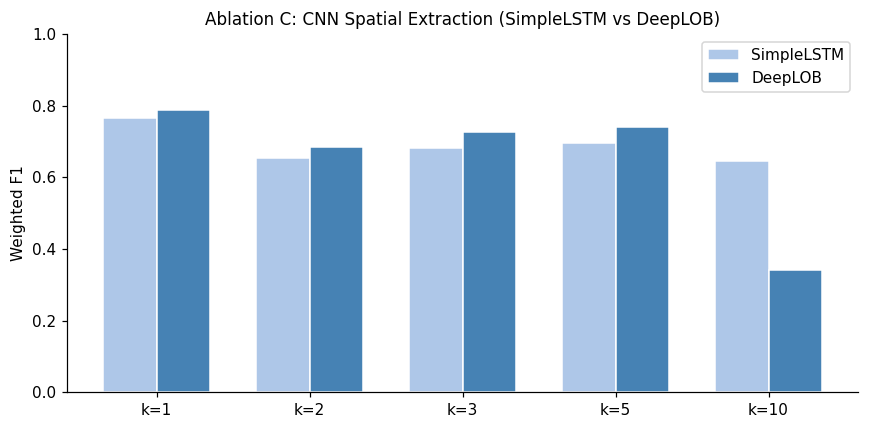

In [10]:
tbl_c = build_results_table({
    'SimpleLSTM (temporal only)':       neural['lstm'],
    'DeepLOB (CNN + temporal)':         neural['deeplob'],
})
print('Ablation C — CNN Spatial Extraction (weighted F1):')
print(tbl_c.to_string(float_format='{:.4f}'.format))

delta_c = tbl_c.loc['DeepLOB (CNN + temporal)'] - tbl_c.loc['SimpleLSTM (temporal only)']
print('\nDelta (DeepLOB − SimpleLSTM):')
print(delta_c.to_string(float_format='{:+.4f}'.format))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(HORIZONS))
w = 0.35
ax.bar(x - w/2, [r['weighted_f1'] for r in neural['lstm']],    w, label='SimpleLSTM', color='#aec7e8', edgecolor='white')
ax.bar(x + w/2, [r['weighted_f1'] for r in neural['deeplob']], w, label='DeepLOB',    color='steelblue', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([f'k={k}' for k in HORIZONS])
ax.set_ylabel('Weighted F1'); ax.set_ylim(0, 1)
ax.set_title('Ablation C: CNN Spatial Extraction (SimpleLSTM vs DeepLOB)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'ablation_c_cnn.png'), bbox_inches='tight')
plt.show()

### Key finding

The CNN spatial extraction consistently helps at short horizons (+2–5% F1 at k=1–5), confirming that explicitly encoding bid/ask level structure improves short-range prediction. At k=10 the effect reverses sharply (−30.7% F1). The convolutional filters learn fine-grained level-by-level imbalances that are highly predictive in the short run but do not generalise when the target is 10 events out. The plain LSTM, having no spatial inductive bias, degrades gracefully.


## 6. Backtest-Style Proxy Simulation

Trading rule from paper Section V.D: buy at t+5 on up signal, hold until down signal; short on down signal, hold until up signal. The public FI-2010 CSV features are z-score normalized and do not include reliable day identifiers after concatenation, so this is reported as **proxy P&L in normalized mid-price units**, not real trading profit. Positions are force-closed at detected contiguous stock/segment boundaries.

In [11]:
# Mid-prices aligned exactly to SlidingWindowDataset outputs
example_ds = SlidingWindowDataset(X_test, Y_test, window=WINDOW, horizon_idx=0)
mid_prices = extract_mid_prices(X_test)[WINDOW - 1: WINDOW - 1 + len(example_ds)]
segment_boundaries = infer_segment_boundaries(mid_prices, n_segments=5)

print(f'Mid-price series length: {len(mid_prices):,}  (one per test window)')
print(f'Segment boundaries: {segment_boundaries}')
print('Note: P&L is in normalized mid-price units; FI-2010 public features are z-scored.')

backtest_results = {}

for h_idx, k in enumerate(HORIZONS):
    model = load_checkpoint(DeepLOB(), os.path.join(MODELS, f'deeplob_k{k}.pt')).eval().to(DEVICE)
    preds = get_nn_preds(model, X_test, Y_test, h_idx)
    bt = run_backtest(preds, mid_prices, boundaries=segment_boundaries)
    tstat = compute_tstat(bt['segment_pnl'])
    backtest_results[k] = {**bt, 'tstat': tstat}
    print(f'  k={k:>2}  segment_pnl={bt["segment_pnl"]}  t-stat={tstat:.3f}  n_trades={bt["n_trades"]}')

Mid-price series length: 31,837  (one per test window)
Segment boundaries: [0, 1789, 6917, 12639, 18460, 31837]
Note: P&L is in normalized mid-price units; FI-2010 public features are z-scored.
  k= 1  segment_pnl=[-0.01617947220802307, 0.02403491735458374, 0.0009742379188537598, -0.02500283718109131, -0.0318988561630249]  t-stat=-0.956  n_trades=1537
  k= 2  segment_pnl=[-0.019134074449539185, -0.005382418632507324, 0.02353551983833313, -0.01175999641418457, -0.05055594444274902]  t-stat=-1.062  n_trades=1680
  k= 3  segment_pnl=[-0.037274718284606934, -0.03236430883407593, 0.019614428281784058, -0.01225501298904419, -0.09611356258392334]  t-stat=-1.671  n_trades=1880
  k= 5  segment_pnl=[-0.01669338345527649, -0.03971594572067261, 0.009314149618148804, -0.009800195693969727, -0.12997639179229736]  t-stat=-1.529  n_trades=1887
  k=10  segment_pnl=[-0.012273460626602173, 0.02059406042098999, -0.0029512643814086914, -0.020599305629730225, 0.10496556758880615]  t-stat=0.786  n_trades=948

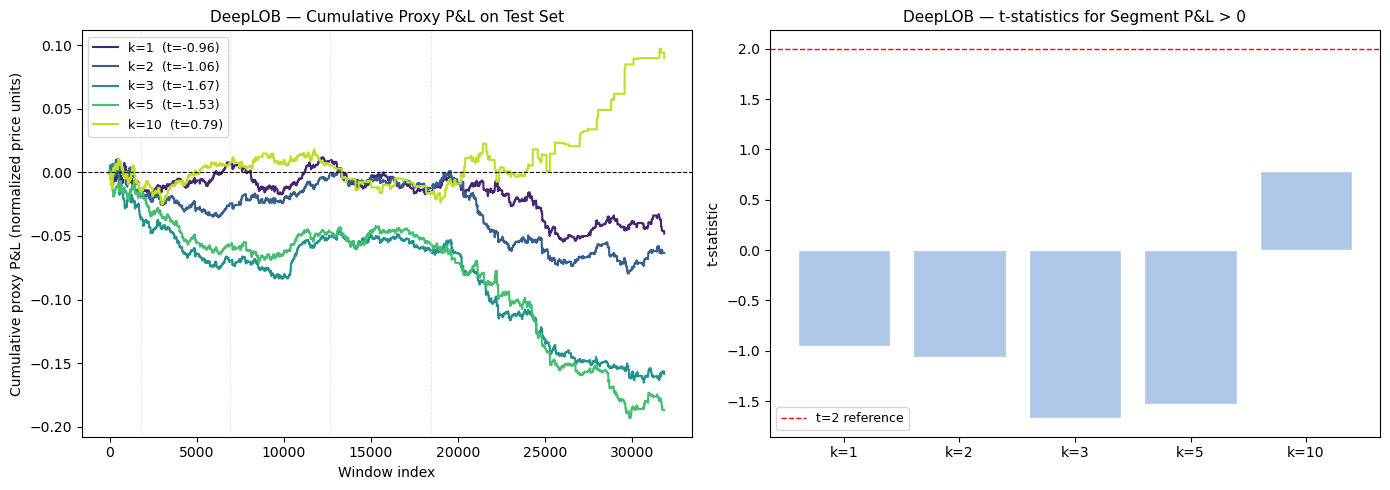


Backtest summary:
    segment_pnl_mean  t_statistic  n_trades
1            -0.0096      -0.9565 1537.0000
2            -0.0127      -1.0620 1680.0000
3            -0.0317      -1.6706 1880.0000
5            -0.0374      -1.5291 1887.0000
10            0.0179       0.7865  948.0000


In [12]:
# Cumulative proxy P&L plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(HORIZONS)))
for (k, bt), color in zip(backtest_results.items(), colors):
    axes[0].plot(bt['cumulative_pnl'], label=f'k={k}  (t={bt["tstat"]:.2f})', color=color, lw=1.5)
for boundary in segment_boundaries[1:-1]:
    axes[0].axvline(boundary, color='0.85', lw=0.7, linestyle=':')
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('DeepLOB — Cumulative Proxy P&L on Test Set', fontsize=11)
axes[0].set_xlabel('Window index')
axes[0].set_ylabel('Cumulative proxy P&L (normalized price units)')
axes[0].legend(fontsize=9)

# t-statistics bar chart
tstats = [backtest_results[k]['tstat'] for k in HORIZONS]
bar_colors = ['#2ca02c' if t > 2 else '#aec7e8' for t in tstats]
axes[1].bar([f'k={k}' for k in HORIZONS], tstats, color=bar_colors, edgecolor='white')
axes[1].axhline(2.0, color='red', linestyle='--', lw=1, label='t=2 reference')
axes[1].set_title('DeepLOB — t-statistics for Segment P&L > 0', fontsize=11)
axes[1].set_ylabel('t-statistic'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'backtest.png'), bbox_inches='tight')
plt.show()

# Summary table
bt_df = pd.DataFrame({
    k: {'segment_pnl_mean': np.mean(backtest_results[k]['segment_pnl']),
        't_statistic':    backtest_results[k]['tstat'],
        'n_trades':       backtest_results[k]['n_trades']}
    for k in HORIZONS
}).T
print('
Backtest summary:')
print(bt_df.to_string(float_format='{:.4f}'.format))

### Interpretation

No horizon produces a statistically significant positive segment-level t-statistic. After closing positions at detected contiguous FI-2010 stock/segment boundaries instead of artificial equal thirds of the test file, the earlier apparent k=3/k=5 profitability disappears. This is the more conservative interpretation: DeepLOB has directional classification signal at short horizons, but the normalized-price proxy backtest does not demonstrate robust tradable profit on this short public benchmark.

## 7. Error Analysis

Which horizons are hardest? What does the model predict instead?
Focus on DeepLOB — the primary model.

In [13]:
print('DeepLOB — Per-class F1 breakdown across horizons:')
print(f'{"":8}  {"k=1":>8}  {"k=2":>8}  {"k=3":>8}  {"k=5":>8}  {"k=10":>8}')
for cls, cls_name in enumerate(['down  ', 'stat. ', 'up    ']):
    row = f'{cls_name}:  '
    for r in neural['deeplob']:
        row += f'  {r["per_class_f1"][cls]:.4f}  '
    print(row)

print('\nDeepLOB — Per-class Recall (how many real events were caught):')
for cls, cls_name in enumerate(['down  ', 'stat. ', 'up    ']):
    row = f'{cls_name}:  '
    for r in neural['deeplob']:
        row += f'  {r["per_class_recall"][cls]:.4f}  '
    print(row)

DeepLOB — Per-class F1 breakdown across horizons:
               k=1       k=2       k=3       k=5      k=10
down  :    0.5998    0.5344    0.6601    0.7205    0.3951  
stat. :    0.8811    0.8053    0.8085    0.7903    0.4214  
up    :    0.6045    0.5123    0.6266    0.6902    0.2148  

DeepLOB — Per-class Recall (how many real events were caught):
down  :    0.4873    0.4495    0.6235    0.7128    0.3879  
stat. :    0.9500    0.9128    0.8845    0.8416    0.5767  
up    :    0.5282    0.4111    0.5383    0.6338    0.1558  


In [14]:
# Error pattern: at k=1, what does DeepLOB predict when it's wrong?
dlob_k1 = load_checkpoint(DeepLOB(), os.path.join(MODELS, 'deeplob_k1.pt')).eval().to(DEVICE)
preds_k1 = get_nn_preds(dlob_k1, X_test, Y_test, 0)
y_true_k1 = Y_test[WINDOW - 1:-1, 0]

# Confusion matrix for k=1
cm_k1 = get_confusion_matrix(y_true_k1, preds_k1)
errors_k1 = cm_k1.copy()
np.fill_diagonal(errors_k1, 0)

print('DeepLOB k=1 — Error confusion matrix (diagonal zeroed):')
print('Rows = true class, Cols = predicted class')
df_err = pd.DataFrame(errors_k1, index=['True: down', 'True: stat.', 'True: up'],
                      columns=['Pred: down', 'Pred: stat.', 'Pred: up'])
print(df_err)

total_errors = errors_k1.sum()
print(f'\nTotal errors: {int(total_errors):,}  ({total_errors / len(y_true_k1) * 100:.1f}% of test set)')
print(f'Most common error: true={CLASS_NAMES[errors_k1.max(axis=1).argmax()]} '
      f'predicted as {CLASS_NAMES[errors_k1.argmax(axis=1)[errors_k1.max(axis=1).argmax()]]}')

DeepLOB k=1 — Error confusion matrix (diagonal zeroed):
Rows = true class, Cols = predicted class
             Pred: down  Pred: stat.  Pred: up
True: down            0         2347       478
True: stat.         443            0       622
True: up            315         2052         0

Total errors: 6,257  (19.7% of test set)
Most common error: true=down predicted as stat.


### Interpretation

Stationary is the easiest class to predict at every horizon — it is the most frequent class and reflects small mid-price movements that recent order book state predicts reliably. Up and down are roughly symmetric in difficulty. DeepLOB's directional recall improves from k=1 to k=5 as the model has more training signal to distinguish movements, then collapses at k=10 as the CNN features stop generalising.

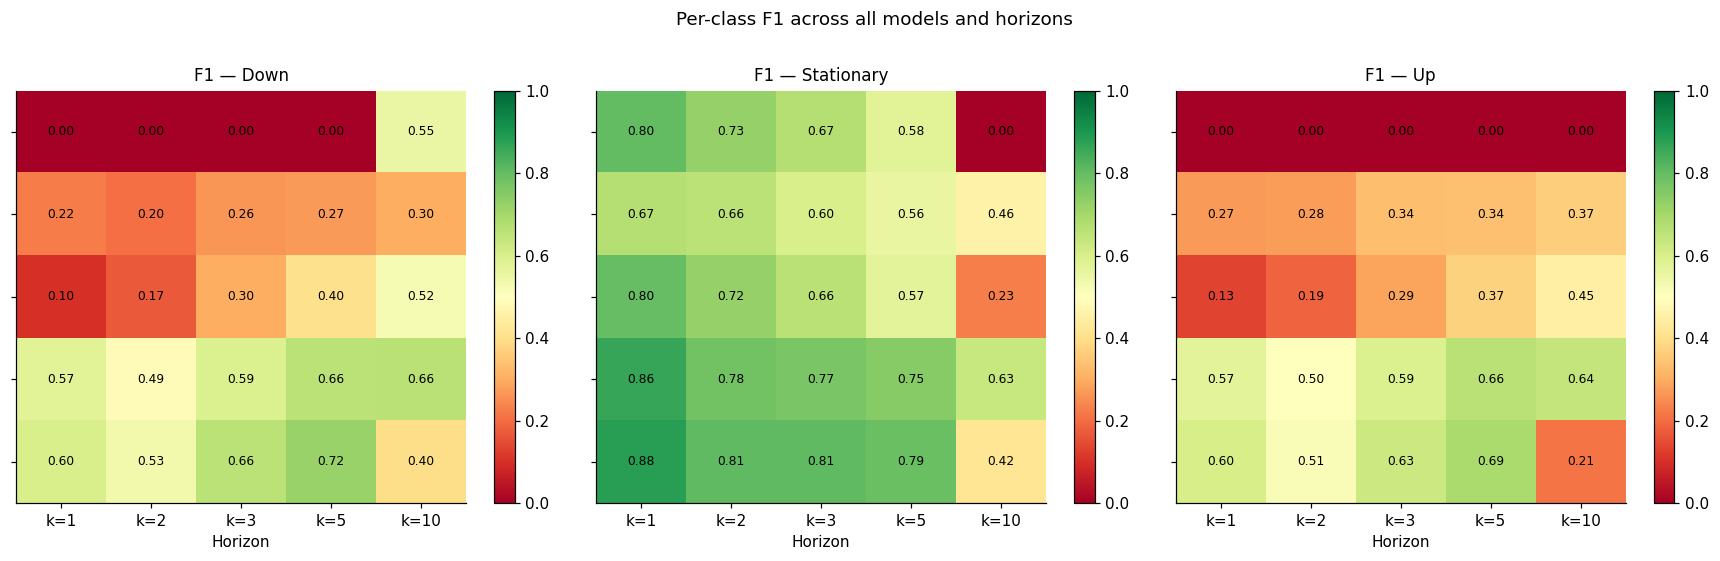

In [15]:
# Per-class F1 heatmap across all models and horizons
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
model_order = ['Majority', 'Logistic', 'XGBoost', 'SimpleLSTM', 'DeepLOB']
result_lists = [classical['majority'], classical['logistic'], classical['xgboost'],
                neural['lstm'], neural['deeplob']]

for ax, cls, cls_name in zip(axes, [0, 1, 2], ['Down', 'Stationary', 'Up']):
    data = np.array([[r['per_class_f1'][cls] for r in res] for res in result_lists])
    im = ax.imshow(data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(HORIZONS))); ax.set_xticklabels([f'k={k}' for k in HORIZONS])
    ax.set_yticks(range(len(model_order))); ax.set_yticklabels(model_order if cls == 0 else [])
    for i in range(len(model_order)):
        for j in range(len(HORIZONS)):
            ax.text(j, i, f'{data[i,j]:.2f}', ha='center', va='center', fontsize=8)
    ax.set_title(f'F1 — {cls_name}', fontsize=11)
    ax.set_xlabel('Horizon')
    plt.colorbar(im, ax=ax)

fig.suptitle('Per-class F1 across all models and horizons', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'per_class_f1.png'), bbox_inches='tight')
plt.show()

### Error analysis summary

At k=1, DeepLOB misclassifies 19.7% of test windows. The dominant error is confusing directional movement with stationary: 2,347 true-down events predicted stationary, 2,052 true-up events predicted stationary. This is a rational response to class imbalance — the model hedges toward the majority class under uncertainty. The per-class heatmap confirms this pattern holds across all models and horizons: stationary F1 is consistently the highest column, and the largest gains from classical → neural are in the directional classes.

## 8. Final Summary

In [16]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print('\nWeighted F1 on test set (days 8–10):')
print(table.to_string(float_format='{:.4f}'.format))

print('\nInference throughput:')
for name, tput in throughputs.items():
    print(f'  {name:<12}  {tput:>12,.0f} pred/s')

print('\nBacktest t-statistics (DeepLOB, segment proxy P&L > 0):')
for k in HORIZONS:
    tstat = backtest_results[k]['tstat']
    sig = '✓ significant' if tstat > 2 else '  not significant'
    print(f'  k={k:>2}  t={tstat:>6.3f}  {sig}')

print('\nFigures saved to results/:')
for fname in sorted(os.listdir(RESULTS)):
    if fname.endswith('.png'):
        print(f'  {fname}')

FINAL RESULTS SUMMARY

Weighted F1 on test set (days 8–10):
              k=1    k=2    k=3    k=5   k=10
Majority   0.5352 0.4131 0.3389 0.2341 0.2123
Logistic   0.5297 0.4779 0.4498 0.4057 0.3677
XGBoost    0.5733 0.4895 0.4811 0.4623 0.4169
SimpleLSTM 0.7667 0.6554 0.6817 0.6956 0.6472
DeepLOB    0.7888 0.6844 0.7273 0.7404 0.3406

Inference throughput:
  Majority       277,402,268 pred/s
  Logistic         4,776,245 pred/s
  XGBoost            125,294 pred/s
  SimpleLSTM         302,284 pred/s
  DeepLOB             83,472 pred/s

Backtest t-statistics (DeepLOB, segment proxy P&L > 0):
  k= 1  t=-0.956    not significant
  k= 2  t=-1.062    not significant
  k= 3  t=-1.671    not significant
  k= 5  t=-1.529    not significant
  k=10  t= 0.786    not significant

Figures saved to results/:
  ablation_c_cnn.png
  ablations_classical.png
  backtest.png
  class_distribution.png
  confusion_matrices_k10.png
  deeplob_curves_k1.png
  deeplob_curves_k10.png
  deeplob_curves_k2.png
  deepl